In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir("..")

from utils import clean_utils

Una persona que empieza a jugar a *League of Legends* puede pensar fácilmente que la mejor manera de ganar una partida es pelear constantemente con los personajes del equipo rival para intentar eliminarlos. En realidad, eliminar campeones es una manera más entre muchas de conseguir oro, que es el recurso más importante del juego. El oro también se puede conseguir de otras maneras como eliminando minions.

Vamos a explorar la primera hipótesis: "Las métricas económicas (oro y minions) tienen una relación más fuerte con la victoria que las métricas de combate (kills, deaths y assists)."

In [ ]:
individual_stats = pd.read_csv("datasets/individual_stats.csv", sep=",")

En primer lugar, debemos conseguir las columnas que buscamos estadísticas relacionadas con el combate:
- "Kills", "Deaths", "Assists"

y las relacionadas con el oro:
- "TotalGold"
- "MinionsKilled"

Sin embargo, antes de poder comparar, es necesario recalcar que *League of Legends* es un juego de equipo. El oro individual de un miembro no cuenta toda la historia de una partida.

Lo que de verdad buscamos saber es la **diferencia** de estas métricas entre los 2 equipos. Para ello, primero debemos extraer las estadísticas de los "SummonerMatchId" que forman partidas válidas ("MatchId" que se repitan 10 veces y que tengan 5 ganadores y perdedores).

Llamamos a nuestra función *construct_valid_teams* para extraer las filas que cumplen este requisito.

In [ ]:
individual_stats_10 = clean_utils.construct_valid_teams(individual_stats)
print(individual_stats_10["MatchId"].nunique()) 
print(individual_stats_10.groupby("MatchId")["Win"].sum().unique())  

19588
[5]


Ahora que tenemos los datos válidos. Ya podemos empezar con el análisis: 
1. Agrupamos por partida y por win/loss 
2. Sumamos todos los stats 
3. Guardamos las columnas generadas en un nuevo dataframe mediante *reset_index()*

In [4]:
team = individual_stats_10.groupby(["MatchId", "Win"]).agg(
    total_gold=("TotalGold", "sum"),
    total_minions=("MinionsKilled", "sum"),
    total_kills=("kills", "sum"),
    total_deaths=("deaths", "sum"),
    total_assists=("assists", "sum")
).reset_index()

team.head()


,MatchId,Win,total_gold,total_minions,total_kills,total_deaths,total_assists
0,KR_7803811288,0,35966,407,16,37,19
1,KR_7803811288,1,50727,496,37,16,50
2,KR_7803863675,0,51100,600,24,34,25
3,KR_7803863675,1,63198,563,34,24,38
4,KR_7806964269,0,75944,873,35,46,56


Ahora que tenemos las métricas totales que queremos analizar, vamos a comparar la distribución de cada una respecto a la columna "Win".

Para ver las diferencias entre distribuciones, vamos a utilizar un *violinplot*.
- Si de verdad una variable influye en derrota o victoria, ambas distribuciones estarán claramente diferenciadas.

Text(0.5, 1.02, 'Distribution of metrics by match outcome')

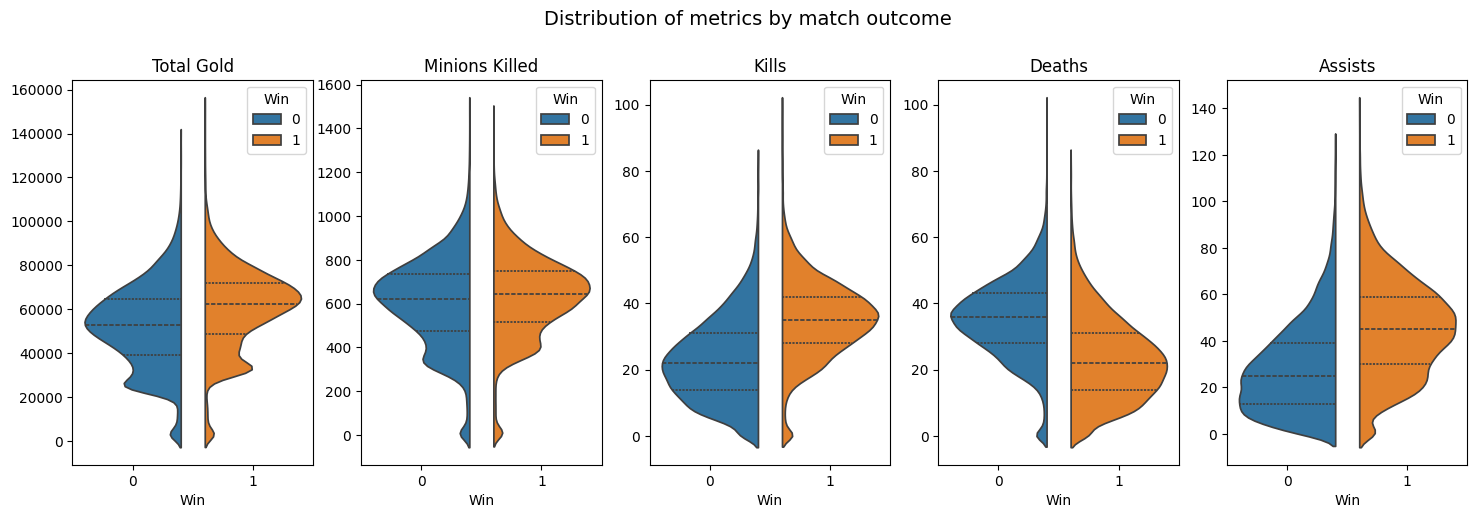

In [ ]:
metrics = {
    "total_gold": "Total Gold",
    "total_minions": "Minions Killed",
    "total_kills": "Kills",
    "total_deaths": "Deaths",
    "total_assists": "Assists"
}
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (col, label) in zip(axes, metrics.items()):
    sns.violinplot(data=team, x="Win", y=col, hue="Win", split=True, inner="quart", ax=ax)
    ax.set_title(label)
    ax.set_xlabel("Win")
    ax.set_ylabel("")

fig.suptitle("Distribución de métricas por resultado de partida", fontsize=14, y=1.02)
# plt.tight_layout()


Se puede observar que las 2 distribuciones de todas las variables (menos los minions) están claramente diferenciadas.
- Sin embargo, observando simplemente estos plots es complicado ver si, por ejemplo, las kills tienen más influencia sobre el resultado de la partida que el oro total.

Para ello, vamos a calcular la diferencia de cada variable entre el equipo ganador y el perdedor.

In [6]:
match_wide = team.pivot(index="MatchId", columns="Win", values=[
    "total_gold", "total_minions", "total_kills", "total_deaths", "total_assists"
])

# Compute winner minus loser differences
match_wide["gold_diff"] = match_wide["total_gold"][1] - match_wide["total_gold"][0]
match_wide["minions_diff"] = match_wide["total_minions"][1] - match_wide["total_minions"][0]
match_wide["kills_diff"] = match_wide["total_kills"][1] - match_wide["total_kills"][0]
match_wide["deaths_diff"] = match_wide["total_deaths"][1] - match_wide["total_deaths"][0]
match_wide["assists_diff"] = match_wide["total_assists"][1] - match_wide["total_assists"][0]


Ahora, vamos a calcular cúantas veces el equipo que tiene una ventaja (diferencia > 0) gana la partida (*Winrate*).
- Para visualizarlo de manera clara comparamos el *Winrate* de cada variable mediante un *barplot*.

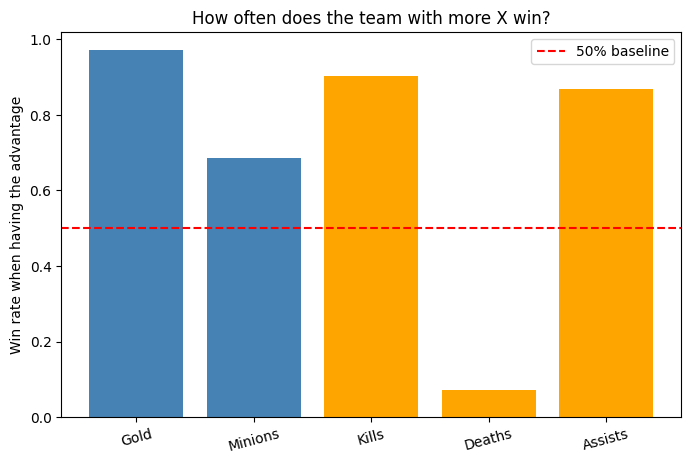

In [ ]:
metrics_diff = {
    "Gold": "gold_diff",
    "Minions": "minions_diff", 
    "Kills": "kills_diff",
    "Deaths": "deaths_diff",
    "Assists": "assists_diff",
}

win_rates = {}
for name, col in metrics_diff.items():
    mask = match_wide[col] > 0  # Mark games where the team that won also has the advantage on the metric ( >0 ) 
    win_rate = mask.mean()  # Compute the average

    win_rates[name] = win_rate  # Store it

labels = list(win_rates.keys())
values = list(win_rates.values())

colors = [
    "orange" if label in ["Kills", "Deaths", "Assists"] else "steelblue"
    for label in labels
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(labels, values, color=colors)

ax.axhline(0.5, color="red", linestyle="--", label="50% baseline")

ax.set_ylabel("Win rate cuando tiene la ventaja")
ax.set_title("Como de probable es que el equipo con más X gane?")

ax.legend()
plt.xticks(rotation=15)
ax.legend()

Al final, una ventaja de oro sí que resulta más determinante que una ventaja de Kills o Asistencias. Sin embargo, a diferencia de lo propuesto inicialmente, la ventaja de minions resulta muchos menos determinante de lo esperado.
- Esto puede ser porque un equipo puede acumular los mismos minions que el otro, pero estar por detrás en oro debido a que el otro equipo tiene más kills u objetivos.

Ahora, vamos con la segunda hipótesis: "El control de objetivos grupal (torres, dragones y barones) está más asociado al resultado de la partida que las estadísticas individuales de combate".
- Al igual que antes, vamos a crear un dataframe agregando las variables que nos interesan.

Para este dataframe, cambiaremos las columnas del dataset que están dividididas en "BlueTowerKills", "RedTowerKills", "BlueDragonKills", "RedDragonKills", "BlueWin", "RedWin", ... en simplemente un dataframe que tiene las variables de un equipo (independientemente de si es azul o rojo) y si ha ganado o no.

In [8]:
group_stats = pd.read_csv("datasets/group_stats.csv", sep=",")
blue = group_stats[["MatchId", "BlueTowerKills", "BlueDragonKills", "BlueBaronKills", "BlueRiftHeraldKills", "BlueKills", "BlueWin"]].copy()
blue.columns = ["MatchId", "TowerKills", "DragonKills", "BaronKills", "HeraldKills", "Kills", "Win"]

red = group_stats[["MatchId", "RedTowerKills", "RedDragonKills","RedBaronKills", "RedRiftHeraldKills", "RedKills", "RedWin"]].copy()
red.columns = ["MatchId", "TowerKills", "DragonKills", "BaronKills", "HeraldKills", "Kills", "Win"]

team_stats = pd.concat([blue, red], ignore_index=True)
team_stats["DragonKills"].value_counts()

DragonKills
2    69297
1    65000
0    58341
3    57836
4    34493
5     5054
6      340
7       23
8        2
Name: count, dtype: int64

Para ver la correlación entre el control de objetivos y la victoria. Vamos a utilizar un *heatmap*.
- Primero, calculamos la matriz de correlación entre todas las variables.
- Creamos los *heatmaps*: 
    - Uno para la relación entre todas las variables. 
    - Otro para su relación únicamente con la victoria.

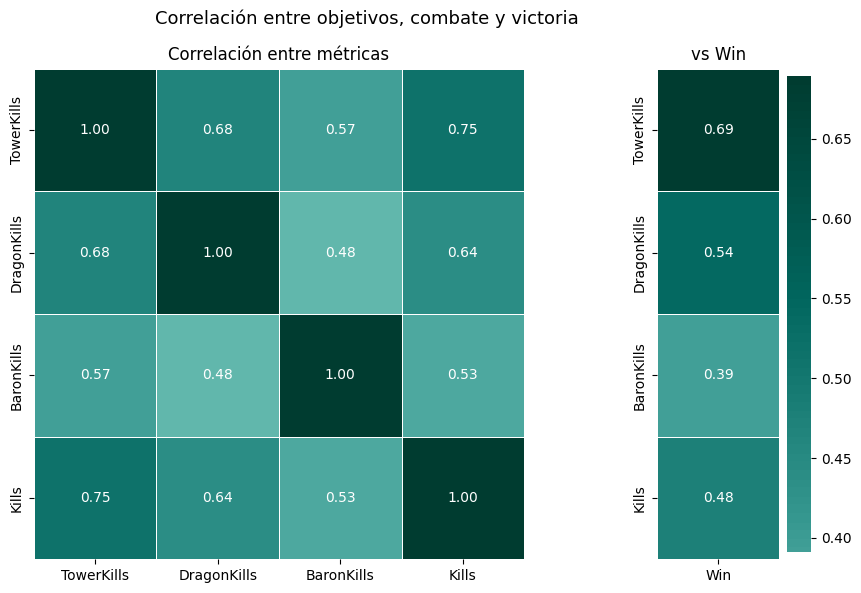

In [ ]:
metrics = {
    "TowerKills": "Torres",
    "DragonKills": "Dragones",
    "BaronKills": "Barones",
    "Kills": "Kills"
}

fig, axes = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={"width_ratios": [5, 1]})

corr_matrix = team_stats[list(metrics.keys()) + ["Win"]].corr()

# Heatmap principal sin Win
sns.heatmap(
    corr_matrix.drop("Win").drop("Win", axis=1),
    annot=True, fmt=".2f", cmap="BrBG", center=0,
    square=True, linewidths=0.5, ax=axes[0], cbar=False
)
axes[0].set_title("Correlación entre métricas")

# Columna Win sola
sns.heatmap(
    corr_matrix.drop("Win")[["Win"]],
    annot=True, fmt=".2f", cmap="BrBG", center=0,
    square=True, linewidths=0.5, ax=axes[1], cbar=True
)
axes[1].set_title("vs Win")
axes[1].set_ylabel("")

fig.suptitle("Correlación entre objetivos, combate y victoria", fontsize=13)
plt.tight_layout()

Podemos observar que el control de torretas es el objetivo más importante, seguido de los dragones.
- También observamos que ni el control de barones ni las kills llegan a un 0.5 de correlación.

A pesar de que las kills no tienen tanta importancia a la hora de ganar una partida, en la otra matriz se puede ver que conseguir kills sí que te puede aportar más objetivos (sobre todo torres y dragones).

Aunque hayamos confirmado la segunda hipótesis, vamos a realizar un análisis sobre cómo cambia el *WinRate* en función del número de objetivos que se van acumulando durante una partida.
- Creamos un simple *lineplot*.


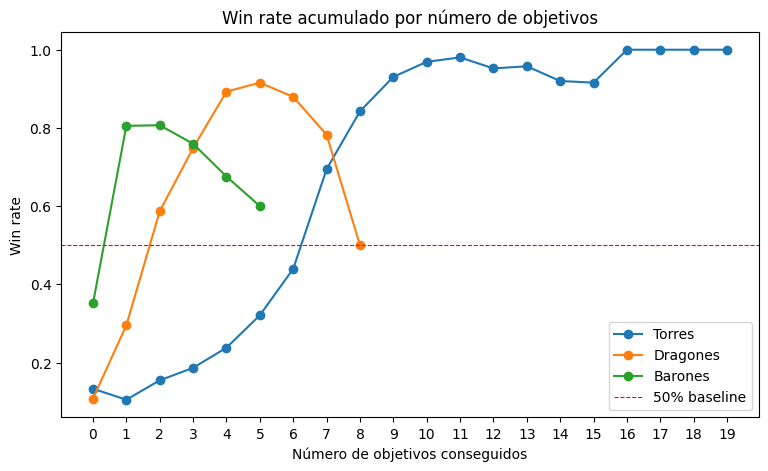

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

objective_cols = {
    "TowerKills": "Torres",
    "DragonKills": "Dragones",
    "BaronKills": "Barones",
}

for col, label in objective_cols.items():
    win_rate_by_obj = team_stats.groupby(col)["Win"].mean()
    ax.plot(win_rate_by_obj.index, win_rate_by_obj.values, marker="o", label=label)

ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="50% baseline")
ax.set_xlabel("Número de objetivos conseguidos")
ax.set_ylabel("Win rate")
ax.set_title("Win rate acumulado por número de objetivos")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.legend()

Como se esperaba, el número de torres es el mejor indicativo de una partida ganada.

Por otra parte, ocurre algo muy interesante con el número de Dragones y Barones:
- A partir de 5 dragones, el *Winrate* comienza a bajar.
- A partir de 2 barones, el *Winrat* comienza a bajar.

Esto puede parecer contraintuitivo respecto a lo que hemos visto, pero tiene una explicación.
- Si un equipo no consigue terminar la partida tras haber conseguido los primeros objetivos significa que el equipo contrario ha resistido a pesar de tener esos objetivos en contra y ha conseguido igualar la ventaja que tenía el equipo ganador.
 - Básicamente, acumular torres literalmente implica ganar la partida, mientras que acumular objetivos no garantiza la victoria a no ser que los conviertas en torres.